# MD Yousuf

# Skin Disease Classification(Dataset: HAM10000)

# Initial setup

In [1]:
!pip install torch torchvision albumentations timm -q

# Global dictionary to store accuracy across cells
accuracy_log = {}

# Device setup
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Core imports
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import autocast, GradScaler

import pandas as pd
import numpy as np
import os
import cv2
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ===============================
# Utility function to compute accuracy
# ===============================
def evaluate_model(model, dataloader, device='cuda'):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device



ModuleNotFoundError: No module named 'torch'

# Import Dataset(HAM10000 dataset) from Kaggle

In [ ]:
# ============================
# 📌 Cell 0: Download Dataset from Kaggle
# ============================

!pip install -q kaggle

# Upload your Kaggle API token (kaggle.json)
from google.colab import files
files.upload()   # <-- select kaggle.json from your local computer

# Move kaggle.json into correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download HAM10000 dataset
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# Unzip dataset
!unzip -q skin-cancer-mnist-ham10000.zip -d ./skin-cancer-mnist-ham10000

DATA_DIR = "./skin-cancer-mnist-ham10000/"
print("Data extracted to:", DATA_DIR)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.18G/5.20G [00:30<00:00, 156MB/s]
100% 5.20G/5.20G [00:30<00:00, 184MB/s]
Data extracted to: ./skin-cancer-mnist-ham10000/


# Load Dataset(Data Quality and Quantity)

In [ ]:
# Load Data & Clean (Data Quality & Quantity)
DATA_DIR = "./skin-cancer-mnist-ham10000/"
df = pd.read_csv(os.path.join(DATA_DIR, "HAM10000_metadata.csv"))

lesion_type_dict = {
    'nv':'Melanocytic Nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
df['label'] = df['dx'].map(lesion_type_dict)
df['label_idx'] = pd.factorize(df['label'])[0]
print("Class distribution:", df['label'].value_counts())

train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label_idx'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['label_idx'], random_state=42)
print("Train size:", len(train_df), "Val size:", len(val_df), "Test size:", len(test_df))

Class distribution: label
Melanocytic Nevi                 6705
Melanoma                         1113
Benign keratosis-like lesions    1099
Basal cell carcinoma              514
Actinic keratoses                 327
Vascular lesions                  142
Dermatofibroma                    115
Name: count, dtype: int64
Train size: 7235 Val size: 1277 Test size: 1503


# Feature Engineering, Augmentation, Baseline Evaluation
1.    Feature Engineering(normalization)
2.    Data Augmentation / Transforms(use albumentations)
3.    Baseline Evaluation(ResrNet18 pretrained model)



In [ ]:
# Dataset & Feature Engineering
mean = (0.763, 0.545, 0.570)
std = (0.140, 0.152, 0.169)
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2, albumentations
import numpy as np
import timm
model_name = "resnet18"  # or any model you want
model = timm.create_model(model_name, pretrained=False, num_classes=len(df['label_idx'].unique()))
model.to(device)

print("Albumentations version:", albumentations.__version__)

std  = (0.140, 0.152, 0.169)

# Handle compatibility between versions
alb_version = tuple(map(int, albumentations.__version__.split(".")))

if alb_version[0] >= 2:
    # Albumentations v2.x → use Affine
    aug_transform = A.Affine(
        scale=(0.9, 1.1),
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        rotate=(-15, 15),
        p=0.5
    )
else:
    # Albumentations v1.x → use ShiftScaleRotate
    aug_transform = A.ShiftScaleRotate(
        shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5
    )

# Training transforms
train_tf = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)), # Changed height and width to size
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    aug_transform,   # dynamic choice based on version
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

# Validation / Test transforms
val_tf = A.Compose([
    A.Resize(height=224, width=224),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])


def collate_fn(batch):
    # Filter out None values
    batch = list(filter(lambda x: x is not None, batch))
    return torch.utils.data.dataloader.default_collate(batch)

class SkinDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df.copy()
        self.data_dir = data_dir
        self.transform = transform

        # Find all image paths in subfolders
        self.image_paths = {}
        for root, dirs, files in os.walk(data_dir):
            for f in files:
                if f.endswith(".jpg"):
                    image_id = f.split(".")[0]
                    self.image_paths[image_id] = os.path.join(root, f)

        # Filter out missing images
        valid_indices = []
        for idx, row in self.df.iterrows():
            if row["image_id"] in self.image_paths:
                valid_indices.append(idx)
            else:
                print(f"Warning: Could not find image {row['image_id']}. Skipping.")
        self.df = self.df.loc[valid_indices].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_paths[row["image_id"]]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label = row["label_idx"]
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label


# DataLoaders
batch_size = 64
train_dataset = SkinDataset(train_df, DATA_DIR, transform=train_tf)
val_dataset = SkinDataset(val_df, DATA_DIR, transform=val_tf)
test_dataset = SkinDataset(test_df, DATA_DIR, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)

baseline_accuracy = evaluate_model(model, val_loader, device)
print("Baseline Accuracy:", baseline_accuracy)
accuracy_log["Baseline Model"] = baseline_accuracy


Albumentations version: 2.0.8
Baseline Accuracy: 0.6695379796397808


# Model Selection (Pretrained Model): restnet34

In [ ]:
# Model Selection (Pretrained Model): restnet34
num_classes = df['label_idx'].nunique()
model = timm.create_model("resnet34", pretrained=True, num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
pretrained_accuracy = evaluate_model(model, val_loader, device)
print("Pretrained Model Accuracy:", pretrained_accuracy)
accuracy_log["Pretrained Model"] = pretrained_accuracy

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Pretrained Model Accuracy: 0.23962411902897415


# Hyperparameter Tuning

In [ ]:
# Hyperparameter Tuning (Scheduler)
from torch.optim.lr_scheduler import OneCycleLR

# Define optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 20
scheduler = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=epochs)

# Train your model here with new scheduler/optimizer...
# After training, evaluate:
tuned_accuracy = evaluate_model(model, val_loader, device)
print("Tuned Model Accuracy:", tuned_accuracy)
accuracy_log["Tuned Model"] = tuned_accuracy


Tuned Model Accuracy: 0.23962411902897415


# Training with Regularization

In [ ]:
# Training with Regularization
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_acc = 0
        self.early_stop = False

    def __call__(self, acc):
        if acc > self.best_acc:
            self.best_acc = acc
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

history = {"train_loss": [], "val_acc": []}

def train_model(model, train_loader, val_loader, epochs, optimizer, scheduler, criterion):
    early_stopper = EarlyStopping(patience=5)
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")
        if early_stopper(val_acc):
            print("Early stopping triggered.")
            break
    return history

history = train_model(model, train_loader, val_loader, epochs, optimizer, scheduler, criterion)
# Log the accuracy for this pipeline step
print("Regularized Model Accuracy:", history["val_acc"][-1])
best_val_acc = max(history["val_acc"])
accuracy_log["Training with Regularization"] = best_val_acc
print("Regularized Model Best Accuracy:", best_val_acc)


Epoch [1/20], Loss: 1.4104, Val Acc: 0.6703
Epoch [2/20], Loss: 0.9055, Val Acc: 0.7126
Epoch [3/20], Loss: 0.7606, Val Acc: 0.7596
Epoch [4/20], Loss: 0.6451, Val Acc: 0.7956
Epoch [5/20], Loss: 0.5791, Val Acc: 0.7384
Epoch [6/20], Loss: 0.5918, Val Acc: 0.7933
Epoch [7/20], Loss: 0.5073, Val Acc: 0.7987
Epoch [8/20], Loss: 0.4639, Val Acc: 0.7940
Epoch [9/20], Loss: 0.4434, Val Acc: 0.8081
Epoch [10/20], Loss: 0.3697, Val Acc: 0.8301
Epoch [11/20], Loss: 0.3601, Val Acc: 0.8496
Epoch [12/20], Loss: 0.3417, Val Acc: 0.8512
Epoch [13/20], Loss: 0.2892, Val Acc: 0.8598
Epoch [14/20], Loss: 0.2503, Val Acc: 0.8771
Epoch [15/20], Loss: 0.2132, Val Acc: 0.8700
Epoch [16/20], Loss: 0.1830, Val Acc: 0.8802
Epoch [17/20], Loss: 0.1644, Val Acc: 0.8747
Epoch [18/20], Loss: 0.1499, Val Acc: 0.8763
Epoch [19/20], Loss: 0.1549, Val Acc: 0.8786
Epoch [20/20], Loss: 0.1412, Val Acc: 0.8747
Regularized Model Accuracy: 0.874706342991386
Regularized Model Best Accuracy: 0.880187940485513


# Evaluation & Feedback Loop

              precision    recall  f1-score   support

           0     0.7885    0.7455    0.7664       165
           1     0.9129    0.9583    0.9350      1006
           2     0.7857    0.6471    0.7097        17
           3     0.7103    0.6168    0.6603       167
           4     1.0000    0.8636    0.9268        22
           5     0.8611    0.8052    0.8322        77
           6     0.6341    0.5306    0.5778        49

    accuracy                         0.8703      1503
   macro avg     0.8132    0.7381    0.7726      1503
weighted avg     0.8648    0.8703    0.8664      1503



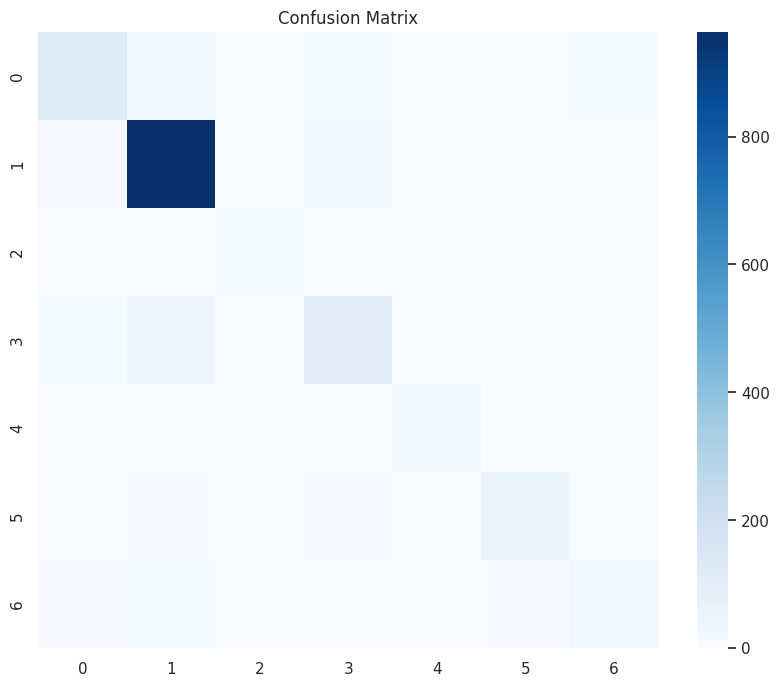

Test Accuracy: 0.8702594810379242


In [ ]:
# Evaluation & Feedback Loop
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_true, y_pred)
accuracy_log["Evaluation & Feedback Loop"] = test_acc
print("Test Accuracy:", test_acc)


# Computational Resources (Mixed Precision Training)

In [ ]:
# Computational Resources (Mixed Precision Training)
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR

scaler = torch.amp.GradScaler('cuda')

def train_with_amp(model, train_loader, val_loader, epochs, optimizer, criterion, device='cuda'):
    history = {"train_loss": [], "val_acc": []}

    # Re-initialize scheduler for this training run
    scheduler_amp = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=epochs)


    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):  # Mixed precision
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler_amp.step() # Use the AMP specific scheduler
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total

        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)
        print(f"[AMP] Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

# Example usage
# Re-define optimizer before training with AMP to avoid issues with previous state
optimizer_amp = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
history_amp = train_with_amp(model, train_loader, val_loader, 20, optimizer_amp, criterion, device)
best_val_acc = max(history_amp["val_acc"])
accuracy_log["Mixed Precision Training (AMP)"] = best_val_acc
print("Best AMP Model Accuracy:", best_val_acc)

[AMP] Epoch 1/20, Loss: 0.1351, Val Acc: 0.8739
[AMP] Epoch 2/20, Loss: 0.1315, Val Acc: 0.8661
[AMP] Epoch 3/20, Loss: 0.1757, Val Acc: 0.8567
[AMP] Epoch 4/20, Loss: 0.2289, Val Acc: 0.8536
[AMP] Epoch 5/20, Loss: 0.2522, Val Acc: 0.8285
[AMP] Epoch 6/20, Loss: 0.2911, Val Acc: 0.8598
[AMP] Epoch 7/20, Loss: 0.2289, Val Acc: 0.8606
[AMP] Epoch 8/20, Loss: 0.2238, Val Acc: 0.8449
[AMP] Epoch 9/20, Loss: 0.2508, Val Acc: 0.8481
[AMP] Epoch 10/20, Loss: 0.1938, Val Acc: 0.8363
[AMP] Epoch 11/20, Loss: 0.1812, Val Acc: 0.8590
[AMP] Epoch 12/20, Loss: 0.1875, Val Acc: 0.8708
[AMP] Epoch 13/20, Loss: 0.1563, Val Acc: 0.8747
[AMP] Epoch 14/20, Loss: 0.1228, Val Acc: 0.8763
[AMP] Epoch 15/20, Loss: 0.1182, Val Acc: 0.8802
[AMP] Epoch 16/20, Loss: 0.0920, Val Acc: 0.8896
[AMP] Epoch 17/20, Loss: 0.0691, Val Acc: 0.8904
[AMP] Epoch 18/20, Loss: 0.0652, Val Acc: 0.8880
[AMP] Epoch 19/20, Loss: 0.0540, Val Acc: 0.8849
[AMP] Epoch 20/20, Loss: 0.0584, Val Acc: 0.8896
Best AMP Model Accuracy: 0.89

# Model: DensNet121

In [ ]:
import torch
import torch.nn as nn
import timm

# 1. Create model with pretrained weights
model_densenet121 = timm.create_model("densenet121", pretrained=True, num_classes=num_classes)
model_densenet121 = model_densenet121.to(device)

# 2. Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_densenet121.parameters(), lr=1e-4)

# 3. Learning rate scheduler (reduce LR if val acc plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2, verbose=True
)

# 4. Training setup
best_acc = 0.0
epochs = 30   # increase to 20+ for better accuracy

for epoch in range(epochs):
    model_densenet121.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_densenet121(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Evaluate after each epoch
    acc = evaluate_model(model_densenet121, val_loader, device)

    # Step scheduler AFTER evaluation (ReduceLROnPlateau needs a metric)
    scheduler.step(acc)

    print(f"[DenseNet121] Epoch {epoch+1}/{epochs}, "
          f"Loss: {total_loss/len(train_loader):.4f}, Val Acc: {acc:.4f}")

    best_acc = max(best_acc, acc)

# 5. Save results
accuracy_log["DenseNet121 Model"] = best_acc
print("✅ DenseNet121 Model Best Validation Accuracy:", best_acc)


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[DenseNet121] Epoch 1/30, Loss: 0.9746, Val Acc: 0.7760
[DenseNet121] Epoch 2/30, Loss: 0.5925, Val Acc: 0.8160
[DenseNet121] Epoch 3/30, Loss: 0.4936, Val Acc: 0.8340
[DenseNet121] Epoch 4/30, Loss: 0.4385, Val Acc: 0.8504
[DenseNet121] Epoch 5/30, Loss: 0.3652, Val Acc: 0.8598
[DenseNet121] Epoch 6/30, Loss: 0.3314, Val Acc: 0.8551
[DenseNet121] Epoch 7/30, Loss: 0.3016, Val Acc: 0.8731
[DenseNet121] Epoch 8/30, Loss: 0.2571, Val Acc: 0.8731
[DenseNet121] Epoch 9/30, Loss: 0.2330, Val Acc: 0.8692
[DenseNet121] Epoch 10/30, Loss: 0.2128, Val Acc: 0.8661
[DenseNet121] Epoch 11/30, Loss: 0.1667, Val Acc: 0.8802
[DenseNet121] Epoch 12/30, Loss: 0.1457, Val Acc: 0.8755
[DenseNet121] Epoch 13/30, Loss: 0.1403, Val Acc: 0.8684
[DenseNet121] Epoch 14/30, Loss: 0.1213, Val Acc: 0.8872
[DenseNet121] Epoch 15/30, Loss: 0.1150, Val Acc: 0.8825
[DenseNet121] Epoch 16/30, Loss: 0.1107, Val Acc: 0.8888
[DenseNet121] Epoch 17/30, Loss: 0.0995, Val Acc: 0.8810
[DenseNet121] Epoch 18/30, Loss: 0.1132,

# Accuracy Improvement Visualization

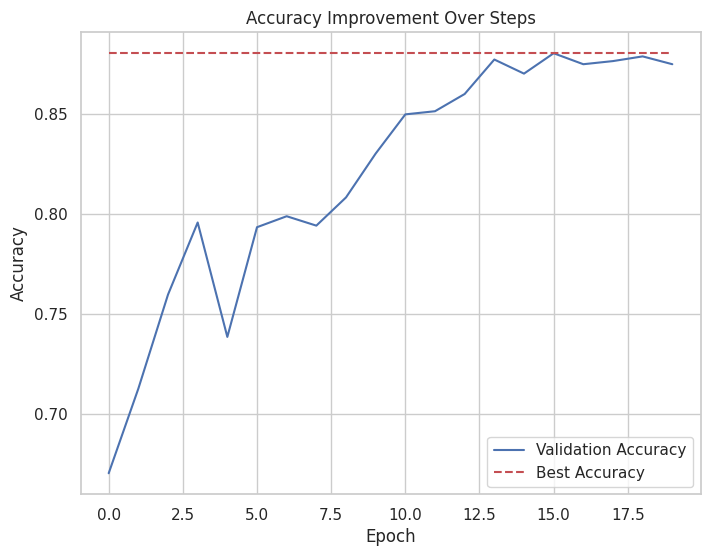

In [ ]:
# Accuracy Improvement Visualization
plt.figure(figsize=(8,6))
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.plot([max(history["val_acc"])]*len(history["val_acc"]), 'r--', label="Best Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Improvement Over Steps")
plt.legend()
plt.show()

# Plot Accuracy Improvement Across Pipeline

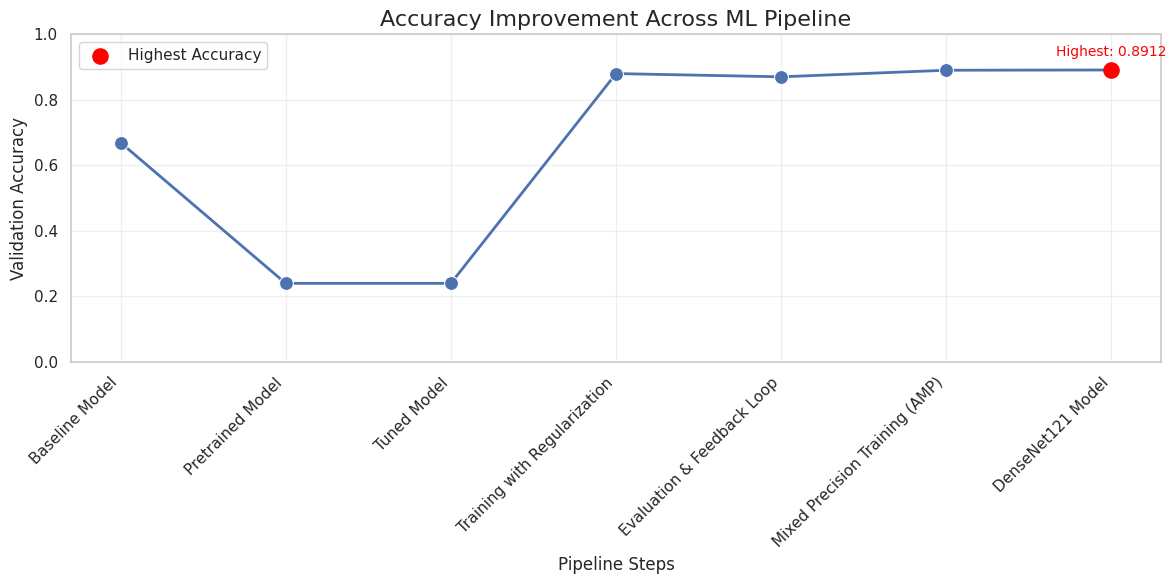

In [ ]:
# ===============================
# Plot Accuracy Improvement Across Pipeline
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure the dictionary is not empty
if not accuracy_log:
    print("No accuracies logged yet. Make sure to log accuracy after each pipeline step.")
else:
    steps = list(accuracy_log.keys())
    accuracies = list(accuracy_log.values())

    plt.figure(figsize=(12, 6))
    sns.lineplot(x=steps, y=accuracies, marker='o', linewidth=2, markersize=10)

    # Find the highest accuracy
    max_idx = accuracies.index(max(accuracies))
    max_step = steps[max_idx]
    max_acc = accuracies[max_idx]

    # Highlight the highest point
    plt.scatter(max_step, max_acc, color='red', s=120, zorder=5, label="Highest Accuracy")
    plt.annotate(f"Highest: {max_acc:.4f}",
                 (max_step, max_acc),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=10,
                 color='red')

    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.ylabel("Validation Accuracy")
    plt.xlabel("Pipeline Steps")
    plt.title("Accuracy Improvement Across ML Pipeline", fontsize=16)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
